# Small project

- Total: 10 points.
- Work in groups of 1 or 2 **(for groups of 2, list each member's individual contributions).**
- Submit: one runnable `.ipynb` with code, figures, and conclusions.
- Deadline: 07.06.2026 23:59

You will compare a multi-view factor model (MOFA) against single-view MOFA/PCA in two settings: a controlled simulation where you know the ground truth, and a real multi-omics dataset of your choice. The point of the exercise is to demonstrate if and when integration helps.

For both tasks: fix a random seed, fit MOFA and single-view MOFA/PCA baselines on each view with the same `K`, and compare all approaches on the same downstream task using the same metric.

---

## Task 1 - Synthetic data

Simulate **two scenarios**, each with 3 views (≥ 200 samples, feature counts of your choice) and a downstream label `y` (binary or continuous).

- **Scenario A - distributed signal.** The latent factor driving `y` loads on all three views and no single view captures it cleanly.
- **Scenario B - concentrated signal.** The factor driving `y` lives in one view only - the other two carry unrelated structure.

For each scenario, fit MOFA and MOFA/PCA on each single view, then compare their performance on a downstream task. Choose and justify your evaluation strategy (e.g. predictive performance of logistic regression evaluated using cross-validation, or a held-out validation split).

## Task 2 - Real data of your choice

Pick a public multi-modal dataset with:
- At least two views.
- At least one categorical covariate (subtype, treatment group, tissue type, mutation status, or similar).

Fit MOFA and MOFA/PCA on each single view, then compare their performance on a downstream task using the evaluation strategy from Task 1. Are there any conclusions that can be drawn from the multi-modal model that cannot be drawn from the single-view models?

---

## Grading

- Task 1 - code (simulation scenarios, fitted models, reproducibility) - 3 points
- Task 1 - discussion and conclusions - 2 points
- Task 2 - code (data preprocessing, fitted models, reproducibility) - 3 points
- Task 2 - discussion and conclusions - 2 points


## Task 1 - code

In [1]:
# Installing MOFA
!pip install mofapy2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 7.3 MB/s eta 0:00:00


In [2]:
import io
import os
import gzip
import urllib.request

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.patches import Patch
from typing import List, Dict, Tuple, Any, Union

import scipy.stats as stats

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import matthews_corrcoef, make_scorer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score, LeaveOneOut

# MOFA
from mofapy2.run.entry_point import entry_point


In [3]:
# Global Variables
K = 5
SEED = 42

# Seed for reproducibility
np.random.seed(SEED)

# Data for Task 2
URL = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE295nnn/GSE295130/suppl/"
FILES = {
    "mRNA": "GSE295130_anno_genes.FPKM.txt.gz",
    "circRNA": "GSE295130_circ_TPM.txt.gz",
    "lncRNA": "GSE295130_lnc_transcripts.readcount.txt.gz"
}

# Metadata
MATRIX_URL = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE295nnn/GSE295130/matrix/GSE295130_series_matrix.txt.gz"
MATRIX_FILE = "GSE295130_series_matrix.txt.gz"


In [4]:
def simulate_data(scenario: str,
                  seed: int = SEED,
                  feature_dict: Dict[str, int] = {"mRNA": 6000, "Methylation": 3000, "Protein": 1000},
                  noise_levels: Dict[str, float] = {"mRNA": 0.8, "Methylation": 0.6, "Protein": 0.8},
                  train_samples: int = 200,
                  val_samples: int = 150,
                  K_true: int = K
                  ) -> Tuple[Dict[str, np.ndarray], pd.DataFrame]:
    """
    Advanced simulation of multi-omics data for Scenarios A and B.
    Returns a dictionary of views and a DataFrame with metadata.
    """
    np.random.seed(seed)

    # Dimension definitions
    N_disc = train_samples
    N_val = val_samples
    N = N_disc + N_val
    D = feature_dict
    view_names = list(D.keys())
    K_true = K_true            # Number of biological latent factors

    # Latent space Z (Samples x Factors)
    Z = np.random.randn(N, K_true)

    if scenario == 'A':
        active = np.array([
            [1, 1, 1],  # F0 (Signal) - Distributed
            [1, 0, 0],  # F1 (Noise)
            [0, 1, 0],  # F2 (Noise)
            [0, 0, 1],  # F3 (Noise)
            [1, 1, 0],  # F4 (Noise)
        ])
        signal_idx = 0
        signal_weight = 0.2

    elif scenario == 'B':
        active = np.array([
            [1, 0, 0],  # F0 (Signal) - Concentrated in mRNA
            [0, 1, 0],  # F1 (Noise)
            [0, 0, 1],  # F2 (Noise)
            [1, 1, 1],  # F3 (Noise)
            [0, 1, 1],  # F4 (Noise)
        ])
        signal_idx = 0
        signal_weight = 2.0
    else:
        raise ValueError("Scenario must be 'A' or 'B'")

    views = {}
    noise_levels = noise_levels

    for m_idx, m in enumerate(view_names):
        W_m = np.zeros((D[m], K_true))
        for k in range(K_true):
            if active[k, m_idx]:
                n_act = D[m] // 4
                idx = np.random.choice(D[m], n_act, replace=False)
                if k == signal_idx and scenario == 'A':
                    W_m[idx, k] = np.random.randn(n_act) * signal_weight
                else:
                    W_m[idx, k] = np.random.randn(n_act) * 1.5

        views[m] = Z @ W_m.T + noise_levels[m] * np.random.randn(N, D[m])

    # Label Generation
    prob = 1 / (1 + np.exp(-1.5 * Z[:, signal_idx]))
    y_binary = (prob > 0.5).astype(int)

    meta = pd.DataFrame({
        "target_y": y_binary,
        "cohort": ["discovery"] * N_disc + ["validation"] * N_val
    }, index=[f"S{i:04d}" for i in range(N)])

    return views, meta


In [5]:
# Generate both scenarios
views_A, y_A = simulate_data(scenario='A')
views_B, y_B = simulate_data(scenario='B')

print(f"Label balance A: {np.bincount(y_A['target_y'])}")
print(f"Label balance B: {np.bincount(y_B['target_y'])}")


Label balance A: [167 183]
Label balance B: [167 183]


In [6]:
def fit_mofa(views_dict: Dict[str, np.ndarray],
             K: int = K,
             seed: int = SEED
             ) -> np.ndarray:
    ent = entry_point()
    view_names = list(views_dict.keys())
    data = [[views_dict[v]] for v in view_names]
    ent.set_data_options(scale_groups=False, scale_views=True)
    ent.set_data_matrix(data, views_names=view_names, groups_names=['group1'])
    ent.set_model_options(factors=K, spikeslab_weights=True, ard_weights=True)
    ent.set_train_options(iter=1000, convergence_mode='medium',
                          seed=seed, verbose=False, gpu_mode=False)
    ent.build()
    ent.run()
    exp = ent.model.getExpectations()
    group_name = list(exp['Z'].keys())[0]
    Z = exp['Z'][group_name]

    if isinstance(Z, dict) and 'E' in Z:
      Z = Z['E']

    if Z.shape[0] == K:
      Z = Z.T

    return Z


def fit_pca_single_view(X: np.ndarray,
                        K: int = K
                        ) -> np.ndarray:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    pca = PCA(n_components=K, random_state=SEED)
    return pca.fit_transform(X_scaled)


def fit_mofa_single_view(X: np.ndarray,
                         K: int = K,
                         view_name: str = 'view',
                         seed: int = SEED) -> np.ndarray:
    return fit_mofa({view_name: X}, K=K, seed=seed)


def evaluate_downstream(Z: np.ndarray,
                        y: Union[np.ndarray, pd.Series],
                        cv_type: str = 'cv5',
                        seed: int = SEED
                        ) -> Tuple[Tuple[float, float], Tuple[float, float]]:
    # Solver for small dataset
    clf = LogisticRegression(max_iter=1000, random_state=seed, solver='liblinear')

    if cv_type == 'loocv':
        cv = LeaveOneOut()
    elif cv_type == 'cv5':
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    else:
        raise ValueError(f"Unknown CV type: {cv_type}")

    mcc_scorer = make_scorer(matthews_corrcoef)
    acc_scores = cross_val_score(clf, Z, y, cv=cv, scoring='accuracy')
    mcc_scores = cross_val_score(clf, Z, y, cv=cv, scoring=mcc_scorer)

    return (acc_scores.mean(), acc_scores.std()), (mcc_scores.mean(), mcc_scores.std())


In [7]:
def run_benchmark(views_dict: Dict[str, np.ndarray],
                  y: Union[np.ndarray, pd.Series],
                  K: int = K,
                  title: str = "Benchmark",
                  cv_type: str = 'loocv'
                  ) -> Dict[str, Tuple[Tuple[float, float], Tuple[float, float]]]:
    """
    General function to run the multi-view benchmark:
    1. Fits integrated MOFA (all views).
    2. Fits single-view PCA and MOFA for each view.
    3. Evaluates all using the specified CV strategy.
    """
    print("=" * 60)
    print(f"RUNNING: {title} (CV: {cv_type})")
    print("=" * 60)

    results = {}

    # Integrated MOFA
    Z_int = fit_mofa(views_dict, K=K)
    res_int = evaluate_downstream(Z_int, y, cv_type=cv_type)
    results[f'MOFA ({len(views_dict)} views)'] = res_int
    print(f"  Integrated MOFA: Acc={res_int[0][0]:.4f}, MCC={res_int[1][0]:.4f}")

    # Single-view baselines
    for name, X in views_dict.items():
        print(f"\nProcessing single view: {name}:")

        # PCA
        Z_pca = fit_pca_single_view(X, K=K)
        res_pca = evaluate_downstream(Z_pca, y, cv_type=cv_type)
        results[f'PCA ({name})'] = res_pca

        # Single-view MOFA
        Z_sv = fit_mofa_single_view(X, K=K, view_name=name)
        res_sv = evaluate_downstream(Z_sv, y, cv_type=cv_type)
        results[f'MOFA ({name})'] = res_sv

        print(f"  {name} PCA:  Acc={res_pca[0][0]:.4f}, MCC={res_pca[1][0]:.4f}")
        print(f"  {name} MOFA: Acc={res_sv[0][0]:.4f}, MCC={res_sv[1][0]:.4f}")

    print("\n" + "=" * 30 + " SUMMARY " + "=" * 30)
    for method, (acc, mcc) in results.items():
        print(f"  {method:25s} | Acc={acc[0]:.4f} | MCC={mcc[0]:.4f}")

    return results


In [8]:
def plot_benchmark_results(results_list: List[Tuple[Dict[str, Tuple[Tuple[float, float], Tuple[float, float]]], str]],
                           chance_level: float = 0.5
                          ) -> None:
    """
    General function to plot Accuracy and MCC for multiple benchmark scenarios.
    results_list: list of tuples (results_dict, plot_title)
    """
    colors_map = {
        'MOFA (All)': '#2E7D32',    # Dark Green
        'MOFA (Single)': '#81C784', # Light Green
        'PCA': '#1976D2'            # Blue
    }

    n_rows = len(results_list)
    fig, axes = plt.subplots(n_rows, 2, figsize=(16, 6 * n_rows), facecolor='#f8f9fa')

    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, (res_dict, s_title) in enumerate(results_list):
        current_colors = []
        labels = sorted(res_dict.keys(), key=lambda x: 'views' not in x.lower())

        acc_means = [res_dict[l][0][0] for l in labels]
        acc_stds = [res_dict[l][0][1] for l in labels]
        mcc_means = [res_dict[l][1][0] for l in labels]
        mcc_stds = [res_dict[l][1][1] for l in labels]

        for l in labels:
            if 'views' in l.lower():
                current_colors.append(colors_map['MOFA (All)'])
            elif 'mofa' in l.lower():
                current_colors.append(colors_map['MOFA (Single)'])
            else:
                current_colors.append(colors_map['PCA'])

        x_pos = np.arange(len(labels))

        axes[i, 0].bar(x_pos, acc_means, yerr=acc_stds, capsize=5, color=current_colors, alpha=0.85, edgecolor='black', linewidth=0.8)
        axes[i, 0].axhline(y=chance_level, color='#d32f2f', linestyle='--', alpha=0.8, label=f'Chance ({chance_level})')
        axes[i, 0].set_title(f"{s_title}\nAccuracy", fontsize=14, fontweight='bold', pad=15)
        axes[i, 0].set_xticks(x_pos)
        axes[i, 0].set_xticklabels(labels, rotation=35, ha='right', fontsize=10)
        axes[i, 0].set_ylim(0, 1.1)
        axes[i, 0].grid(axis='y', linestyle=':', alpha=0.5)

        if i == 0:
          axes[i, 0].legend(loc='lower right')

        axes[i, 1].bar(x_pos, mcc_means, yerr=mcc_stds, capsize=5, color=current_colors, alpha=0.8, edgecolor='black', linewidth=0.8)
        axes[i, 1].axhline(y=0, color='#d32f2f', linestyle='--', alpha=0.8, label='Random Chance (0.0)')
        axes[i, 1].set_title(f"{s_title}\nMCC", fontsize=14, fontweight='bold', pad=15)
        axes[i, 1].set_xticks(x_pos)
        axes[i, 1].set_xticklabels(labels, rotation=35, ha='right', fontsize=10)
        axes[i, 1].set_ylim(-0.2, 1.1)
        axes[i, 1].grid(axis='y', linestyle=':', alpha=0.5)

        if i == 0:
          axes[i, 1].legend(loc='lower right')

    legend_elements = [
        Patch(facecolor=colors_map['MOFA (All)'], edgecolor='black', label='Integrated MOFA'),
        Patch(facecolor=colors_map['MOFA (Single)'], edgecolor='black', label='Single-View MOFA'),
        Patch(facecolor=colors_map['PCA'], edgecolor='black', label='Single-View PCA')
    ]
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3, fontsize=12, frameon=False)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


In [9]:
results_A = run_benchmark(views_A,
                          y_A['target_y'],
                          K=K,
                          title="Scenario A - Distributed Signal",
                          cv_type='cv5'
                          )


RUNNING: Scenario A - Distributed Signal (CV: cv5)

        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Scaling views to unit variance...

Features names not provided, using default naming convention:
- feature1_view1, featureD_viewM

Samples names not provided, using default naming convention:
- sample1_group1, sample2_group1, sample1_group2, ..., sampleN_groupG

Successfully loaded view='mRNA' group='group1' with N=350 samples and D=60

In [10]:
results_B = run_benchmark(views_B,
                          y_B['target_y'],
                          K=K,
                          title="Scenario B - Concentrated Signal",
                          cv_type='cv5'
                          )


RUNNING: Scenario B - Concentrated Signal (CV: cv5)

        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Scaling views to unit variance...

Features names not provided, using default naming convention:
- feature1_view1, featureD_viewM

Samples names not provided, using default naming convention:
- sample1_group1, sample2_group1, sample1_group2, ..., sampleN_groupG

Successfully loaded view='mRNA' group='group1' with N=350 samples and D=6

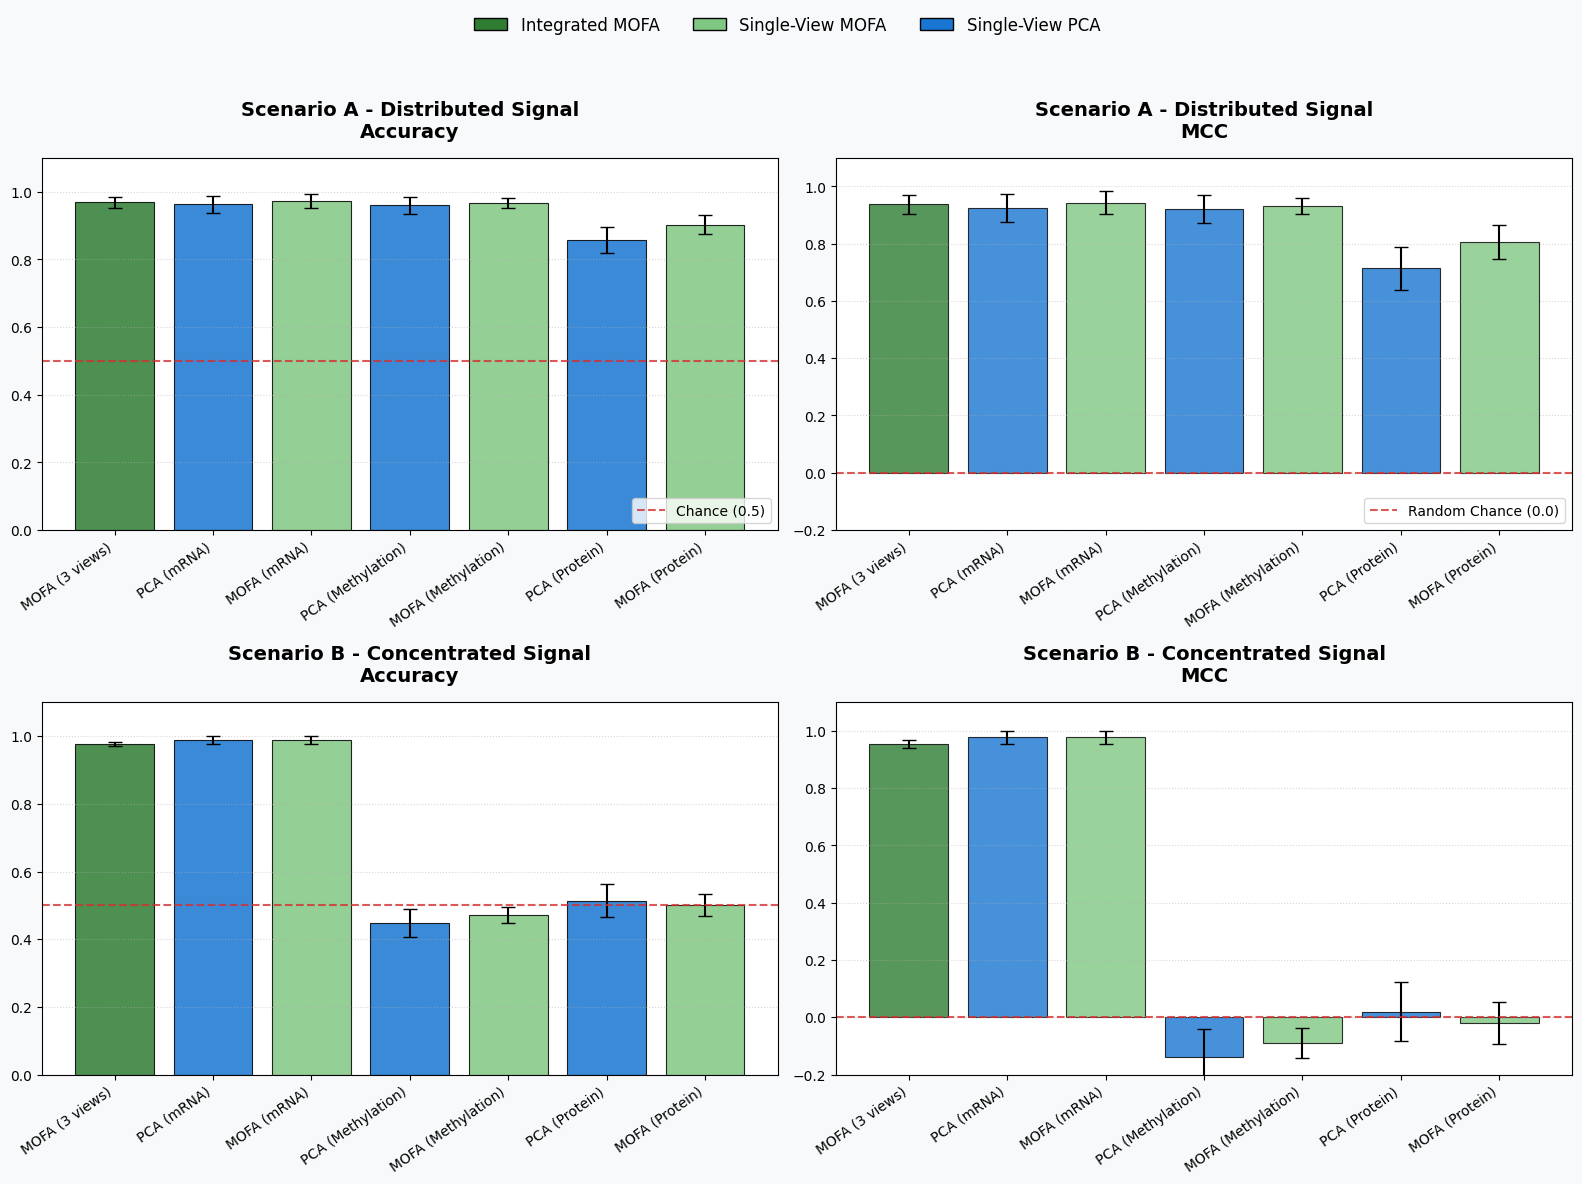

In [11]:
plot_benchmark_results([
    (results_A, 'Scenario A - Distributed Signal'),
    (results_B, 'Scenario B - Concentrated Signal')
], chance_level=0.5)


# Task 1 - discussion and conclusions

## Theoretical Background: PCA vs. MOFA

To understand the simulation results, it is crucial to highlight the differences between single-view and multi-view dimensionality reduction techniques:

* PCA (Principal Component Analysis) is a classic, single-view, linear transformation technique which seeks to identify orthogonal axes (principal components) that maximise the variance within a single dataset [1]. Although powerful for single-omics, PCA cannot naturally bridge multiple datasets in theory. If a biological signal spans a few views and is weak in both, applying PCA to a single layer will likely discard this signal as noise, favouring strong, view-specific technical variance instead.

* MOFA (Multi-Omics Factor Analysis): MOFA is a statistical framework designed specifically for integrating multiple omics layers [2]. Mathematically, it generalises PCA to multi-view data by inferring a shared, low-dimensional latent space. Crucially, MOFA employs Automatic Relevance Determination (ARD) priors. This sparsity-inducing mechanism allows the model to automatically determine whether a latent factor is shared across all views. For example, this could be a global immune response. Alternatively, it could be specific to just one view. In this case, it effectively shrinks irrelevant connections to zero.

## Simulation Results and Conclusions

Our evaluation strategy is a Logistic Regression evaluated with 5-fold CV. We opted for a linear classifier because the latent factors (Z) represent the underlying variance linearly, and 5-fold cross-validation ensures that our evaluation is robust to sample splitting. The classes are well balanced in both tasks. However, in addition to accuracy, we used the Matthews Correlation Coefficient (MCC) to assess the quality of the classifiers and provide a more robust and comprehensive evaluation. It should be noted that, although unsupervised dimensionality reduction (PCA/MOFA) was performed on the entire dataset, the risk of data leakage is minimal. The class labels were completely withheld during the phase of feature extraction, and the supervised Logistic Regression model was strictly trained within the cross-validation folds using the resulting shared latent space.


### Scenario A (Distributed Signal):

In this scenario, the signal driving the labels was distributed across all three synthetic views with varying noise levels (mRNA: 0.8, Methylation: 0.6, and Protein: 0.8) and different numbers of features (mRNA: 6000, Methylation: 3000, Protein: 1000). The signal weight was deliberately kept low ($\texttt{signal_weight} = 0.2$) relative to the structured, view-specific noise.

The integrated MOFA model (three views) achieved excellent predictive performance (Acc = 0.9686). However, the single-view baselines, particularly MOFA_mRNA (Acc = 0.9714) and MOFA_Methylation (Acc = 0.9657), also performed outstandingly, virtually matching or even marginally exceeding the multi-view model. An important conclusion is that, for each individual view, MOFA is slightly better than PCA.

This demonstrates a critical caveat in multi-omics analysis. When a biological signal is already highly separable and strongly present within individual molecular layers, multi-omics integration may not yield a significant boost in pure classification accuracy. Indeed, aligning highly predictive layers (mRNA and Methylation) with slightly weaker layers (Protein, Acc=0.9029) can occasionally introduce a minor penalty for noise or optimisation complexity. Nevertheless, the three-view MOFA model remained highly robust, proving that it can successfully extract the shared latent signal without a meaningful drop in performance.

### Scenario B (Concentrated Signal):

In this scenario, the biological signal was concentrated entirely within the mRNA layer ($\texttt{signal_weight} = 2.0$), while the Methylation and Protein views contained exclusively uninformative structural noise (as evidenced by their ~0.44 to 0.51 accuracy, which is equivalent to random guessing).

As expected, the mRNA-only models performed excellently (PCA_mRNA accuracy = 0.9886). Notably, the integrated multi-view MOFA model also performed remarkably well (Acc=0.9771), despite the significant noise introduced by the other two layers.

This validates the robustness of MOFA's mathematical design. Thanks to its ARD priors, MOFA successfully identified that the latent factor was active only in the mRNA layer. It also effectively disabled the weights for Methylation and Protein. This is a critical feature for real-world biological data, as it demonstrates that multiple omics layers can be safely fed into MOFA without risking the corruption of meaningful layers by noisy or irrelevant omics.


# Task 2 - code

In [12]:
def ensure_file_exists(filename: str,
                       url: str
                       ) -> None:
    """Checks if a file exists locally; if not, downloads it from the provided URL."""
    if not os.path.exists(filename):
        print(f"Downloading {filename}.")
        urllib.request.urlretrieve(url, filename)
    else:
        print(f"File {filename} already exists. Skipping download.")


In [13]:
def get_geo_metadata_mapping(matrix_file: str) -> pd.DataFrame:
    """
    Parses a GEO series matrix file to extract Library IDs, Titles, and Genotypes.
    Returns a DataFrame and a dictionary mapping Internal_ID to Biological_Group.
    """
    metadata_dict = {}
    with gzip.open(matrix_file, 'rt') as f:
        for line in f:
            if line.startswith('!Sample_title'):
                metadata_dict['Title'] = line.strip().split('\t')[1:]
            if line.startswith('!Sample_description'):
                raw_desc = line.strip().split('\t')[1:]
                # Extract short ID from description string (e.g., 'ID:A1' -> 'A1')
                metadata_dict['Library_ID'] = [d.replace('"', '').split(':')[-1] for d in raw_desc]
            if line.startswith('!Sample_characteristics_ch1'):
                if 'genotype' in line:
                    raw_geno = line.strip().split('\t')[1:]
                    metadata_dict['Genotype'] = [g.replace('"', '').replace('genotype: ', '') for g in raw_geno]
            if line.startswith('!series_matrix_table_begin'):
                break

    # Create alignment DataFrame
    mapping_df = pd.DataFrame({
        'Internal_ID': metadata_dict.get('Library_ID'),
        'GEO_Title': metadata_dict.get('Title'),
        'Biological_Group': metadata_dict.get('Genotype')
    })

    return mapping_df


In [14]:
def analyze_omics_view(df: pd.DataFrame, view_label: str):
    """
    Performs a comprehensive structural analysis of a given omics dataframe.
    """
    print(f"<== {view_label} Analysis ==>")
    print(f"Shape: {df.shape}")

    id_cols = [c for c in df.columns if df[c].dtype == 'object']
    sample_cols = [c for c in df.columns if df[c].dtype in ['float64', 'int64', 'float32', 'int32']]

    print(f"ID Columns ({len(id_cols)}): {id_cols}")
    print(f"Sample Columns ({len(sample_cols)}): {sample_cols[:5]}...")

    # Check for missing values
    missing_count = df.isnull().sum().sum()
    if missing_count > 0:
        print(f"[WARNING]: {missing_count} missing values detected.")
    else:
        print("[SUCCESS]: No missing values detected.\n")


In [15]:
# Checking metadata
ensure_file_exists(MATRIX_FILE, MATRIX_URL)

mapping_df = get_geo_metadata_mapping(MATRIX_FILE)
display(mapping_df.head(10))


,Internal_ID,GEO_Title,Biological_Group
0,A1,"""pbmc,HC1""",HC
1,A2,"""pbmc,HC2""",HC
2,A4,"""pbmc,HC3""",HC
3,A5,"""pbmc,HC4""",HC
4,A7,"""pbmc,HC5""",HC
5,A9,"""pbmc,HC6""",HC
6,A10,"""pbmc,HC7""",HC
7,D1,"""pbmc,SLE1""",SLE
8,D2,"""pbmc,SLE2""",SLE
9,D3,"""pbmc,SLE3""",SLE


In [16]:
# Download data
for filename in FILES.values():
    ensure_file_exists(filename, URL + filename)


In [17]:
# Load files to DataFrame
df_mrna = pd.read_csv(FILES['mRNA'], sep='\t', index_col=1)
df_lnc  = pd.read_csv(FILES['lncRNA'], sep='\t', index_col=0)
df_circ = pd.read_csv(FILES['circRNA'], sep='\t', index_col=0)

# Analyze all three views
analyze_omics_view(df_mrna, "mRNA (FPKM)")
analyze_omics_view(df_circ, "circRNA (TPM)")
analyze_omics_view(df_lnc, "lncRNA (Read Count)")


<== mRNA (FPKM) Analysis ==>
Shape: (66332, 28)
ID Columns (2): ['gene_id', 'gene_locus']
Sample Columns (26): ['A1', 'A10', 'A2', 'A4', 'A5']...
[SUCCESS]: No missing values detected.

<== circRNA (TPM) Analysis ==>
Shape: (14588, 26)
ID Columns (0): []
Sample Columns (26): ['A1', 'A10', 'A2', 'A4', 'A5']...
[SUCCESS]: No missing values detected.

<== lncRNA (Read Count) Analysis ==>
Shape: (35402, 26)
ID Columns (0): []
Sample Columns (26): ['A1', 'A10', 'A2', 'A4', 'A5']...
[SUCCESS]: No missing values detected.



In [18]:
def prepare_multi_omics_data(
    raw_views: Dict[str, pd.DataFrame],
    mapping_df: pd.DataFrame,
    top_n_features: Dict[str, int] = None,
    normalize: bool = True
) -> Tuple[Dict[str, np.ndarray], np.ndarray]:
    """
    Integrates raw matrices with metadata, filters patients and features,
    and prepares data for the run_benchmark function.
    """
    print("<== Preparing Multi-omics Data ==>")

    # Extract mapping dictionary from mapping_df
    mapping_clean = mapping_df.dropna(subset=['Internal_ID', 'Biological_Group'])
    exact_mapping = dict(zip(mapping_clean['Internal_ID'], mapping_clean['Biological_Group']))

    # Find common samples across all views and metadata
    common_samples = set(exact_mapping.keys())
    for name, df in raw_views.items():
        common_samples = common_samples.intersection(df.columns)

    selected_samples = sorted(list(common_samples))
    print(f"Synchronized {len(selected_samples)} samples across all matrices.")

    # Create target labels
    y_labels = [exact_mapping[s] for s in selected_samples]
    le = LabelEncoder()
    y_encoded = le.fit_transform(y_labels)
    print(f"Encoded classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")

    views = {}
    if top_n_features is None:
        top_n_features = {}

    scaler = StandardScaler()

    for view_name, df in raw_views.items():
        df_sub = df[selected_samples]
        mat = np.log2(df_sub.values + 1)

        # Filtering by variance
        limit = top_n_features.get(view_name)
        if limit is not None and limit < mat.shape[0]:
            variances = mat.var(axis=1)
            top_idx = np.argsort(variances)[-limit:]
            mat = mat[top_idx, :]
            print(f"  View '{view_name}': Reduced to top {limit} features.")
        else:
            print(f"  View '{view_name}': Kept all {mat.shape[0]} features.")

        mat_t = mat.T

        # Z-score
        if normalize:
            mat_out = scaler.fit_transform(mat_t)
        else:
            mat_out = mat_t

        views[view_name] = mat_out

    return views, y_encoded


In [19]:
top_features_config = {
    'mRNA': 6000,
    'lncRNA': 3000,
    'circRNA': 1000
}

processed_views, y_task2 = prepare_multi_omics_data(
    raw_views={'mRNA': df_mrna, 'lncRNA': df_lnc, 'circRNA': df_circ},
    mapping_df=mapping_df,
    top_n_features=top_features_config,
    normalize=True
)

results_task2 = run_benchmark(
    processed_views,
    y_task2,
    K=K,
    title="Task 2: SLE Multi-Omics (Preprocessed)",
    cv_type='cv5'
)


<== Preparing Multi-omics Data ==>
Synchronized 26 samples across all matrices.
Encoded classes: {np.str_('HC'): np.int64(0), np.str_('RA'): np.int64(1), np.str_('SLE'): np.int64(2), np.str_('SLET'): np.int64(3)}
  View 'mRNA': Reduced to top 6000 features.
  View 'lncRNA': Reduced to top 3000 features.
  View 'circRNA': Reduced to top 1000 features.
RUNNING: Task 2: SLE Multi-Omics (Preprocessed) (CV: cv5)

        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ################################################

In [20]:
processed_views_raw, y_task2_raw = prepare_multi_omics_data(
    raw_views={'mRNA': df_mrna, 'lncRNA': df_lnc, 'circRNA': df_circ},
    mapping_df=mapping_df,
    top_n_features=None,
    normalize=False
)

results_task2_raw = run_benchmark(
    processed_views_raw,
    y_task2_raw,
    K=K,
    title="Task 2: SLE Multi-Omics (Raw)",
    cv_type='cv5'
)


<== Preparing Multi-omics Data ==>
Synchronized 26 samples across all matrices.
Encoded classes: {np.str_('HC'): np.int64(0), np.str_('RA'): np.int64(1), np.str_('SLE'): np.int64(2), np.str_('SLET'): np.int64(3)}
  View 'mRNA': Kept all 66332 features.
  View 'lncRNA': Kept all 35402 features.
  View 'circRNA': Kept all 14588 features.
RUNNING: Task 2: SLE Multi-Omics (Raw) (CV: cv5)

        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


S

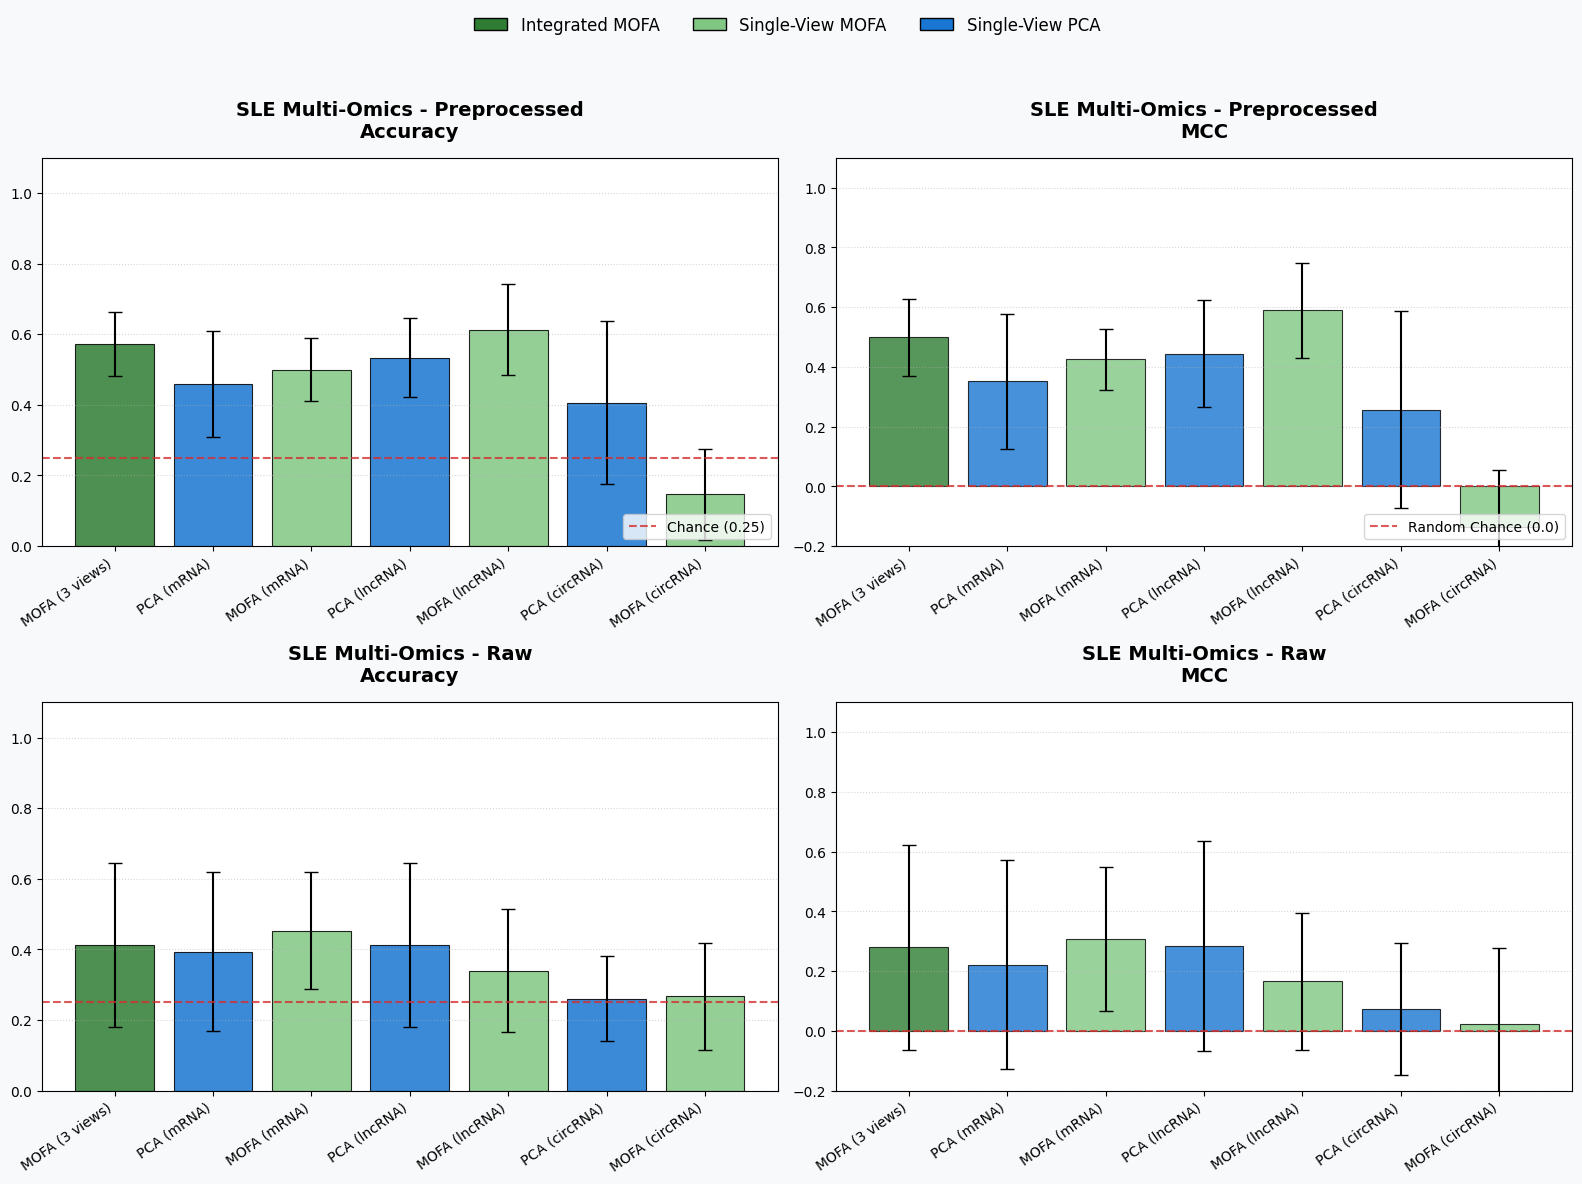

In [21]:
plot_benchmark_results([
    (results_task2, 'SLE Multi-Omics - Preprocessed'),
    (results_task2_raw, 'SLE Multi-Omics - Raw')
], chance_level=0.25)


In [22]:
def calculate_r2(Z: np.ndarray,
                 W: np.ndarray,
                 X: np.ndarray
                 ) -> float:
    """Calculates the Coefficient of Determination (R2) for a given factor and view."""
    X_std = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
    pred = Z @ W.T
    var_total = np.var(X_std)
    var_resid = np.var(X_std - pred)
    return float(max(0, 1 - var_resid / var_total))


In [23]:
# Fit the final integrated model on the preprocessed data
ent = entry_point()
view_names = list(processed_views.keys())
data = [[processed_views[v]] for v in view_names]
ent.set_data_options(scale_groups=False, scale_views=True)
ent.set_data_matrix(data, views_names=view_names, groups_names=['group1'])
ent.set_model_options(factors=K, spikeslab_weights=True, ard_weights=True)
ent.set_train_options(iter=1000, convergence_mode='medium', seed=SEED, verbose=False)
ent.build()
ent.run()



        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Scaling views to unit variance...

Features names not provided, using default naming convention:
- feature1_view1, featureD_viewM

Samples names not provided, using default naming convention:
- sample1_group1, sample2_group1, sample1_group2, ..., sampleN_groupG

Successfully loaded view='mRNA' group='group1' with N=26 samples and D=6000 features...
Successfully loaded view='lncRNA' gro

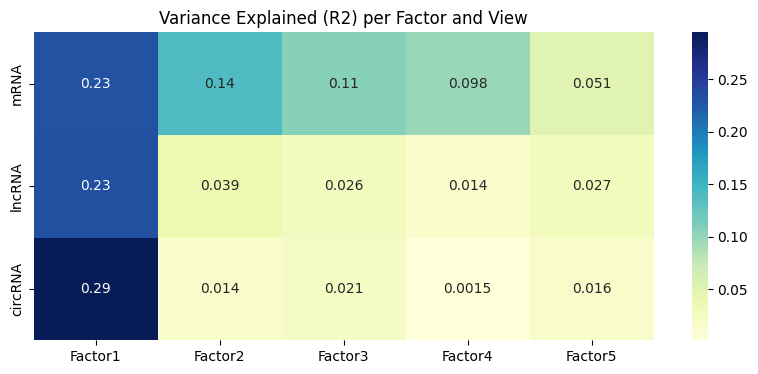

In [24]:
# Extract Expectations
exp = ent.model.getExpectations()
group_name = list(exp['Z'].keys())[0]
factors = exp['Z'][group_name]
weights_list = exp['W']

# Calculate Variance Explained (R2) per factor
r2_matrix = np.zeros((len(view_names), K))
for i, v in enumerate(view_names):
    W_view = weights_list[i]['E'] if isinstance(weights_list[i], dict) else weights_list[i]
    for k in range(K):
        r2_matrix[i, k] = calculate_r2(factors[:, [k]], W_view[:, [k]], processed_views[v])

r2_df = pd.DataFrame(r2_matrix, index=view_names, columns=[f'Factor{i+1}' for i in range(K)])

plt.figure(figsize=(10, 4))
sns.heatmap(r2_df, annot=True, cmap='YlGnBu')
plt.title('Variance Explained (R2) per Factor and View')
plt.show()


In [25]:
def get_top_features(view_label: str,
                     weights_dict: Union[Dict, np.ndarray],
                     feature_names: List[str],
                     n_top: int = 10,
                     factor_idx: int = 0
                     ) -> pd.DataFrame:
    """
    Helper to extract top features based on absolute loading weights
    for a specific factor.
    """
    W = weights_dict['E'][:, factor_idx] if isinstance(weights_dict, dict) else weights_dict[:, factor_idx]

    # Create a DataFrame for sorting
    df_weights = pd.DataFrame({
        'Feature': feature_names,
        'Weight': W,
        'AbsWeight': np.abs(W)
    })

    return df_weights.sort_values('AbsWeight', ascending=False).head(n_top)


def get_filtered_names(raw_df: pd.DataFrame,
                       top_limit: int
                       ) -> List[str]:
    """
    To align feature names with the filtered model weights,
    we recalculate the indices used during preprocessing.
    """
    sample_cols = [c for c in raw_df.columns if raw_df[c].dtype in ['float64', 'int64', 'float32', 'int32']]
    df_numeric = raw_df[sample_cols]

    mat = np.log2(df_numeric.values + 1)
    variances = mat.var(axis=1)
    top_idx = np.argsort(variances)[-top_limit:]
    return raw_df.index[top_idx].tolist()


In [26]:
def plot_latent_space(factors: np.ndarray,
                      mapping_df: pd.DataFrame,
                      selected_samples: List[str],
                      K: int = 5
                      ) -> pd.DataFrame:
    """Visualizes samples in the integrated latent space (Factor 1 vs Factor 2)."""
    z_df = pd.DataFrame(factors, columns=[f'Factor{i+1}' for i in range(K)])
    mapping_clean = mapping_df.dropna(subset=['Internal_ID', 'Biological_Group'])
    exact_mapping = dict(zip(mapping_clean['Internal_ID'], mapping_clean['Biological_Group']))
    z_df['Group'] = [exact_mapping[s] for s in selected_samples]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.scatterplot(data=z_df, x='Factor1', y='Factor2', hue='Group', style='Group', s=100, ax=axes[0])
    axes[0].set_title('Sample Clustering in Integrated Latent Space')

    sns.boxplot(data=z_df, x='Group', y='Factor1', palette='Set2', ax=axes[1])
    axes[1].set_title('Factor 1 Distribution by Biological Group')
    plt.tight_layout()
    plt.show()
    return z_df


def plot_view_correlations(processed_views: Dict[str, np.ndarray],
                           weights_list: List[Union[Dict, np.ndarray]],
                           view_names: List[str],
                           factor_idx: int = 0
                           ) -> pd.DataFrame:
    """Calculates and plots the spearman correlation of Factor scores across views."""
    def get_projection(view_data: np.ndarray, weights_dict: Union[Dict, np.ndarray], f_idx: int) -> np.ndarray:
        W = weights_dict['E'][:, f_idx] if isinstance(weights_dict, dict) else weights_dict[:, f_idx]
        X_std = (view_data - view_data.mean(axis=0)) / view_data.std(axis=0)
        return X_std @ W

    view_scores = {v: get_projection(processed_views[v], weights_list[i], factor_idx) for i, v in enumerate(view_names)}
    view_score_df = pd.DataFrame(view_scores)
    corr_matrix = view_score_df.corr(method='spearman')

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1)
    plt.title(f'Consistency of Factor {factor_idx+1} Signal Across Views')
    plt.show()
    return view_score_df


def plot_cross_view_alignment(view_score_df: pd.DataFrame,
                              group_labels: pd.Series
                              ) -> None:
    """Scatter plots of Factor projections comparing mRNA to other views."""
    df = view_score_df.copy()
    df['Group'] = group_labels.values if hasattr(group_labels, 'values') else group_labels
    other_views = [c for c in df.columns if c != 'mRNA' and c != 'Group']

    fig, axes = plt.subplots(1, len(other_views), figsize=(8 * len(other_views), 7))

    if len(other_views) == 1:
      axes = [axes]

    for i, v in enumerate(other_views):
        sns.scatterplot(data=df, x='mRNA', y=v, hue='Group', style='Group', s=120, ax=axes[i])
        axes[i].set_title(f'Factor 1 Projection: mRNA vs {v}')
    plt.tight_layout()
    plt.show()


def plot_weight_distributions(weights_list: List[Union[Dict, np.ndarray]],
                              view_names: List[str],
                              factor_idx: int = 0
                              ) -> None:
    """Violin plots of feature loadings for a specific factor across views."""
    weights_data = []
    for i, v in enumerate(view_names):
        W = weights_list[i]['E'][:, factor_idx] if isinstance(weights_list[i], dict) else weights_list[i][:, factor_idx]
        for val in W:
            weights_data.append({'View': v, 'Loading Weight': val})

    plt.figure(figsize=(10, 6))
    sns.violinplot(data=pd.DataFrame(weights_data), x='View', y='Loading Weight',
                   palette='muted', inner='quartile')
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.title(f'Feature Weight Distributions for Factor {factor_idx+1}')
    plt.show()


In [27]:
# Extract the specific names for features included in the model
mrna_filtered_names = get_filtered_names(df_mrna, top_features_config['mRNA'])
lnc_filtered_names = get_filtered_names(df_lnc, top_features_config['lncRNA'])
circ_filtered_names = get_filtered_names(df_circ, top_features_config['circRNA'])

# Detect top features for each view for Factor 1
n_plot = 10
top_mrna = get_top_features('mRNA', weights_list[0], mrna_filtered_names, n_top=n_plot)
top_lnc = get_top_features('lncRNA', weights_list[1], lnc_filtered_names, n_top=n_plot)
top_circ = get_top_features('circRNA', weights_list[2], circ_filtered_names, n_top=n_plot)

print("Top 10 mRNA Drivers (Factor 1):")
display(top_mrna)

print("\nTop 10 lncRNA Drivers (Factor 1):")
display(top_lnc)

print("\nTop 10 circRNA Drivers (Factor 1):")
display(top_circ)


Top 10 mRNA Drivers (Factor 1):


,Feature,Weight,AbsWeight
5146,ABCA5,0.672710,0.672710
3107,NOL9,0.662002,0.662002
5245,NR3C2,0.657970,0.657970
1713,TMEM248,0.654287,0.654287
756,LATS1,0.651018,0.651018
3881,AC005261.1,0.649013,0.649013
4549,RRAS2,0.648522,0.648522
3015,GRPEL2,0.645996,0.645996
3371,MFSD6,0.645634,0.645634
4410,ERP27,0.642949,0.642949



Top 10 lncRNA Drivers (Factor 1):


,Feature,Weight,AbsWeight
2358,TCONS_00237505,0.603638,0.603638
1276,TCONS_00558108,0.599157,0.599157
2916,ENST00000514616,0.588662,0.588662
2199,TCONS_00337185,0.587939,0.587939
1145,TCONS_00168794,0.584420,0.584420
2892,TCONS_00407059,0.583623,0.583623
587,TCONS_00336847,0.583407,0.583407
2274,TCONS_00557880,0.579470,0.579470
2224,TCONS_00049553,0.578224,0.578224
2505,TCONS_00129005,0.577227,0.577227



Top 10 circRNA Drivers (Factor 1):


,Feature,Weight,AbsWeight
452,novel_circ_0008579,0.593963,0.593963
435,hsa_circ_0084464,0.580780,0.580780
997,hsa_circ_0001829,0.572219,0.572219
528,hsa_circ_0007996,0.572052,0.572052
325,hsa_circ_0005630,0.568591,0.568591
973,hsa_circ_0018992,0.568062,0.568062
61,hsa_circ_0001195,0.566540,0.566540
630,hsa_circ_0003401,0.562370,0.562370
245,hsa_circ_0005689,0.558111,0.558111
886,novel_circ_0014754,0.556216,0.556216


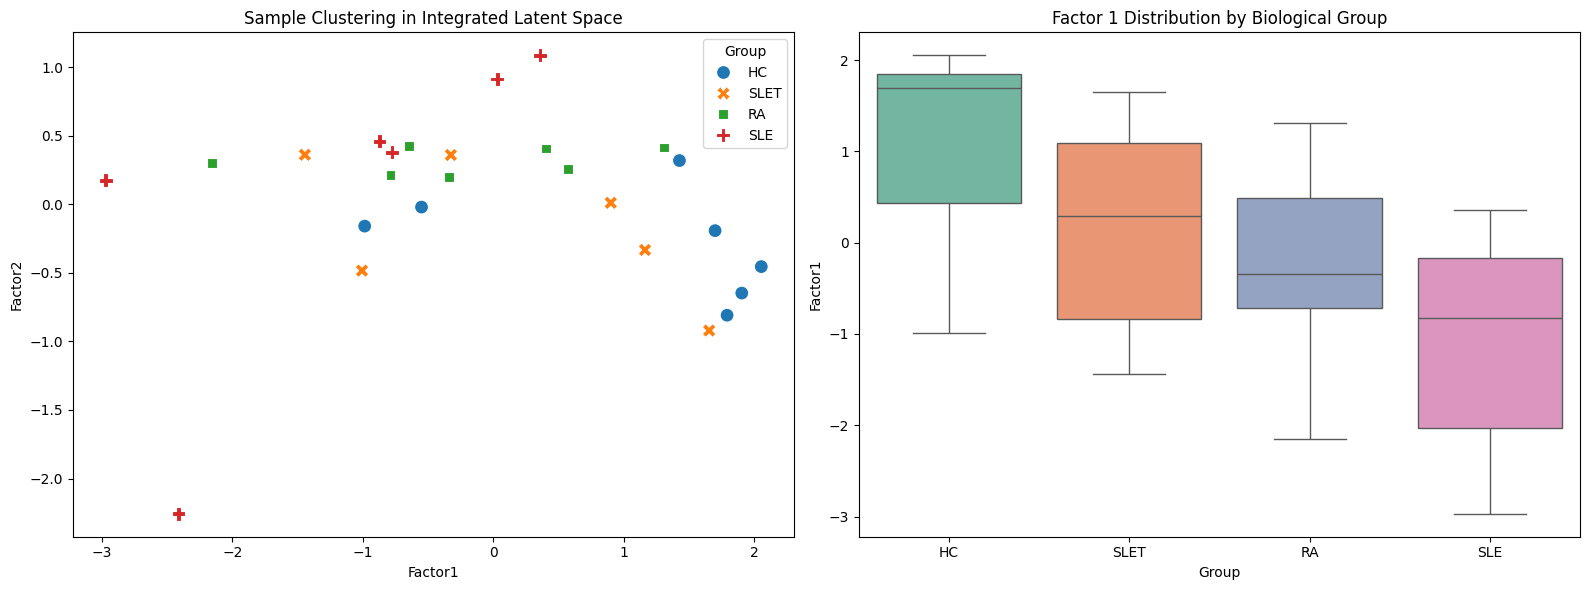

In [28]:
common_samples = set(mapping_df.dropna(subset=['Internal_ID'])['Internal_ID'])

for df in [df_mrna, df_lnc, df_circ]:
    common_samples = common_samples.intersection(df.columns)
selected_samples = sorted(list(common_samples))

# Latent Space
z_df_processed = plot_latent_space(factors, mapping_df, selected_samples)

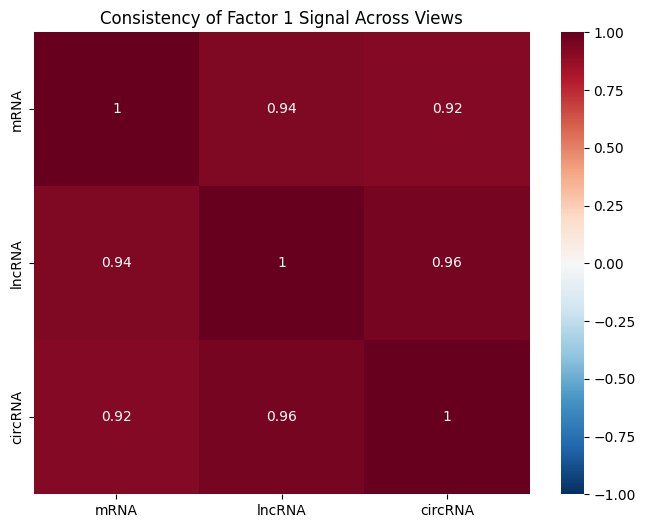

In [29]:
# View Correlations
vs_df = plot_view_correlations(processed_views, weights_list, view_names)


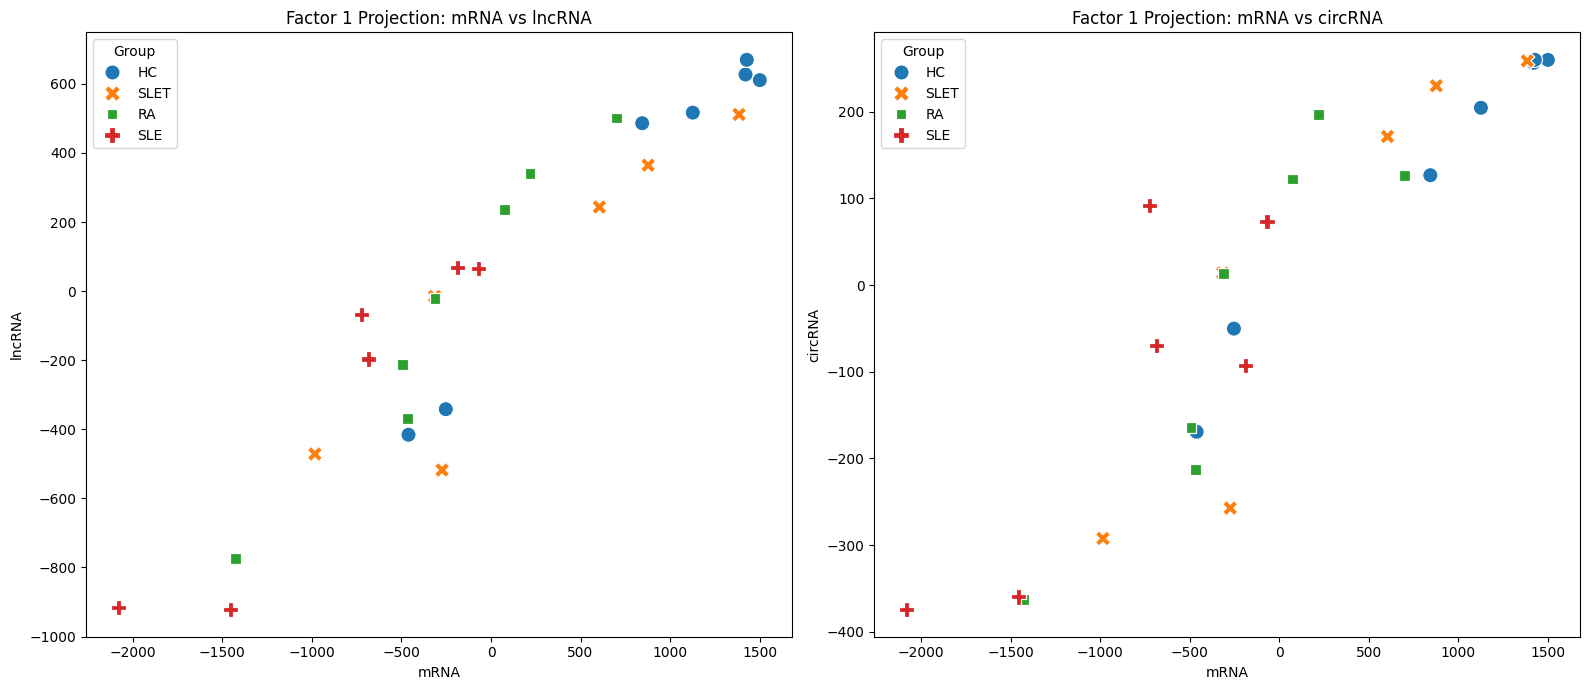

In [30]:
# Alignment Scatter
plot_cross_view_alignment(vs_df, z_df_processed['Group'])


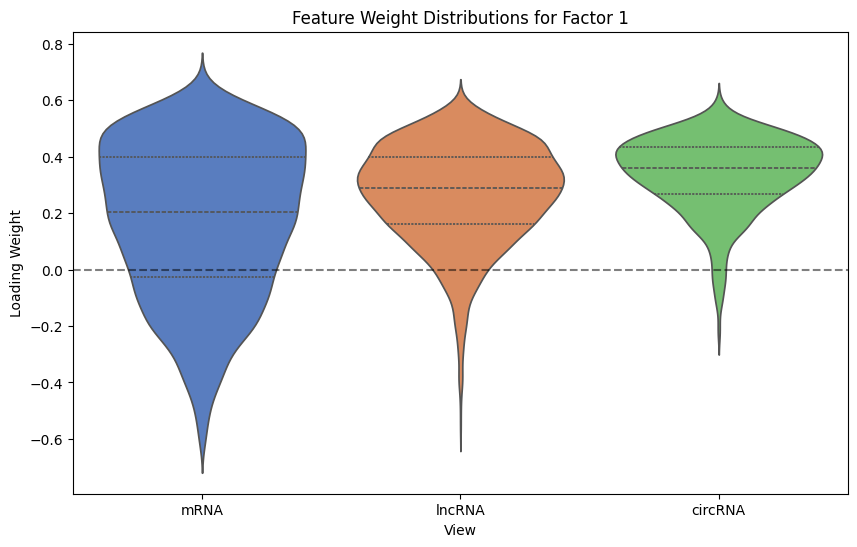

In [31]:
# Weight Distributions
plot_weight_distributions(weights_list, view_names)


# Task 2 - discussion and conclusions

## Dataset Analysis

We used the GSE295130 dataset [3], which contains mRNA, long non-coding RNA (lncRNA) and circular RNA (circRNA) profiles from patients with systemic lupus erythematosus (SLE) and healthy controls. The dataset includes three molecular views:

1.  **mRNA** alone likely captures the strongest individual signal since protein-coding gene expression directly reflects transcriptional changes in immune cells. However, single-view PCA/MOFA on mRNA may perform reasonably well, but miss subtle regulatory information.

2.  **lncRNA** view provides complementary regulatory information and are known to regulate immune responses and SLE pathogenesis (e.g. NEAT1 and MALAT1 are implicated in SLE). The lncRNA view may add discriminative power that is not redundant with mRNA.

3. The **circRNA** view adds unique circular RNA biology: circRNAs act as microRNA sponges and regulate gene expression post-transcriptionally. They provide a distinct layer of information about disease mechanisms.

The categorical covariate is the disease group, consisting of a strictly limited cohort of 26 samples in total: seven healthy controls (HC), seven disease controls (RA), six patients with SLE and six treated SLE patients (SLET).

It is important to note that such a small sample size poses a significant challenge for machine learning (ML) algorithms, especially when contrasted with the highly dimensional nature of multi-omics data (thousands of features per view). This greatly increases the risk of the 'curse of dimensionality' and model overfitting, so robust pre-processing and the regularising effect of multi-view integration (such as MOFA) are absolutely critical for extracting reliable biological signals. Despite the limitations of the sample size, we evaluated the models using 5-fold cross-validation to maintain a consistent and unified evaluation strategy with our analysis of the synthetic data in Task 1.

The original authors found that integrating ATAC-seq and RNA-seq data identified NK cell-mediated cytotoxicity as a therapeutic target in SLE [3]. Similarly, our MOFA analysis of the RNA-seq-derived views (mRNA, lncRNA and circRNA) demonstrates the value of multi-omics integration in discovering coordinated molecular mechanisms in SLE that are invisible to single-view analyses.


## The Crucial role of Preprocessing

Comparing unprocessed and preprocessed data highlights the extreme sensitivity of PCA and MOFA to scale and dimensionality. When applied to raw data, the models performed poorly, struggling to separate the signal from the substantial technical noise present. Applying Z-score normalisation and selecting high-variance features yielded significant improvements. These improvements were across almost all modalities. For example, MOFA 3-views accuracy jumped from 0.4133 to 0.5733. This demonstrates that, without aggressive variance filtering, the curse of dimensionality effectively blinds these algorithms to subtle biological signatures.

Although the integrated multi-view model (Acc = 0.5733) was marginally outperformed by the single-view MOFA lncRNA model (Acc = 0.6133) in terms of pure mean accuracy, focusing solely on the mean can be misleading. Crucially, the integrated 3-view MOFA model exhibited the smallest variance across all MOFA models in the 5-fold cross-validation. This low variance is particularly important given the dataset's extremely small and restricted sample size (only 26 samples in total: seven healthy controls, seven rheumatoid arthritis, six SLE, and six SLE-treated). In such small cohorts, single-view models are highly prone to overfitting to specific training and testing splits. The minimal variance of the integrated model demonstrates the effectiveness of multi-omics integration as a mathematical regulariser. This anchors the model's predictions, providing a much more stable and reliable disease signature.

## Conclusions Drawn exclusively from the Multi-Modal Model

To answer the question: __Are there any conclusions that can be drawn from the multi-modal model that cannot be drawn from the single-view models?__ the answer is absolutely YES. Even if a single view yields higher raw accuracy, the integrated MOFA model provides unique biological insights:

* Cross-Omic Coordination: Single-view models can only tell us that mRNA changes in SLE, and circRNA changes in SLE. They cannot tell us if these changes are linked. The multi-modal MOFA model (specifically the $R^2$ Variance Explained heatmap) mathematically proves that a single latent biological factor is driving changes across mRNA, lncRNA, and circRNA simultaneously. This confirms a coordinated, systemic molecular cross-talk.

* Separation: Only the multi-modal model allows us to decompose the disease signature into "Shared Factors" (e.g., a global immune response affecting all transcript types) and "Specific Factors" (e.g., a process altering only circRNA splicing without affecting standard mRNA).

* Cross-Layer Denoising: Sparse or highly noisy datasets (like the circRNA view, which failed completely on its own) are rescued in the multi-modal space. MOFA leverages the strong, clear signals from the mRNA and lncRNA layers to contextualize the noisy circRNA data, mapping it to the shared disease factors in a way that is mathematically impossible to do if analysing the circRNA matrix in isolation.


## Author Contributions

Both authors contributed equally to completing this project. Jakub Giezgała was responsible for selecting the primary publication, developing the code for Task 2, creating the visualisations and writing the conclusions and discussion for this task. Piotr Kupidura implemented the code for Task 1 and wrote the discussion for this task. He also handled the data retrieval and preparation for Task 2. Additionally, both authors cross-reviewed and refined each other's work to ensure the final report was accurate and of a uniformly high quality.


## References

1. Pearson, K. (1901). On Lines and Planes of Closest Fit to Systems of Points in Space. Philosophical Magazine.

2. Argelaguet, R., Velten, B., Arnol, D., Dietrich, S., Macaulay, I. C., Huber, W., & Stegle, O. (2018). Multi-Omics Factor Analysis—a framework for unsupervised integration of multi-omics data sets. Molecular Systems Biology, 14(6), e8124.

3. Zhang J, Ma L, Deng H, Yi W, Tohtihan A, Tang X, Wu X, Feng X. (2025). Multi-omics integration identifies NK cell-mediated cytotoxicity as a therapeutic target in systemic lupus erythematosus. Front Immunol. 13; 16:1580540.


#